# The FLY25 carry on QueryDrivenBacktest — vol leg, linear leg, and t-costs

The always-on short 1/−2/1 butterfly (front quarterly, struck at the
ZQ-tree mode, rolled at expiry−3d) as a production-engine strategy:

* the **vol leg** is a first-class `STIRFutureOptionStructure.FLY` query
  marked daily through the MDP's QL pricers, roll costs booked in-engine;
* the **linear leg** is an optional SR3 futures delta hedge
  (`STIRFutureQuery`), rebalanced when the package delta drifts past a
  threshold, sized dynamically through `AddQueryFactoryAction`;
* **t-costs are configurable per leg**: `tcost_vol_bp` per option
  contract per side, `tcost_linear_bp` per futures contract per side.

Provenance honesty (findings 2026-08-04): the short-fly carry's NW t has
never cleared 2 — this port is infrastructure for the forward test and
the combined book, not a certification.

In [1]:
CONFIG = dict(
    side="short",            # long | short
    contracts=1.0,
    tcost_vol_bp=0.125,      # per OPTION contract per side (half-tick)
    tcost_linear_bp=0.25,    # per FUTURES contract per side (half-tick)
    vol_tcost_grid=(0.0, 0.125, 0.25),
    linear_tcost_grid=(0.0, 0.25, 0.50),
    hedge=True,              # run the linear-leg variant too
    hedge_threshold=0.5,     # contracts of delta drift before rebalancing
    start=None, end=None,
)
CONFIG

{'side': 'short',
 'contracts': 1.0,
 'tcost_vol_bp': 0.125,
 'tcost_linear_bp': 0.25,
 'vol_tcost_grid': (0.0, 0.125, 0.25),
 'linear_tcost_grid': (0.0, 0.25, 0.5),
 'hedge': True,
 'hedge_threshold': 0.5,
 'start': None,
 'end': None}

In [2]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_fly_qdb import (build_roll_schedule, linear_cost_usd,
                          make_fly_backtest)
from famb_fade_qdb import closed_positions_frame
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from RVUtils.SFRRVLab.stats import nw_tstat

schedule, sessions, holdings = build_roll_schedule(
    CONFIG["start"], CONFIG["end"], return_holdings=True)
print(f"{len(schedule)} holdings over {len(sessions)} sessions "
      f"({sessions[0].date()} -> {sessions[-1].date()})")
print(schedule[["symbol", "low", "mid", "high", "start", "end"]]
      .head(6).to_string(index=False))

18 holdings over 1102 sessions (2022-03-08 -> 2026-07-28)
symbol          low          mid         high      start        end
SFRM22 SFRM22|9875C SFRM22|9900C SFRM22|9925C 2022-03-08 2022-06-06
SFRU22 SFRU22|9750C SFRU22|9775C SFRU22|9800C 2022-06-07 2022-09-12
SFRZ22 SFRZ22|9575C SFRZ22|9600C SFRZ22|9625C 2022-09-13 2022-12-12
SFRH23 SFRH23|9500C SFRH23|9525C SFRH23|9550C 2022-12-13 2023-03-06
SFRM23 SFRM23|9425C SFRM23|9450C SFRM23|9475C 2023-03-07 2023-06-12
SFRU23 SFRU23|9450C SFRU23|9475C SFRU23|9500C 2023-06-13 2023-09-11


## The vol leg alone (unhedged)

In [3]:
opt_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
bt_u, _ = make_fly_backtest(
    schedule, sessions, opt_mdp, contracts=CONFIG["contracts"],
    side=CONFIG["side"], tcost_vol_bp=CONFIG["tcost_vol_bp"],
    show_progress=True)
bt_u.run()
cl_u = closed_positions_frame(bt_u)
eq_u = pd.Series(bt_u.mtm_history).sort_index()
d_u = eq_u.diff().dropna()
print(f"\nunhedged: {len(cl_u)} holdings closed, "
      f"total ${cl_u['realized_pnl'].sum():+,.0f} per 1-lot "
      f"({cl_u['realized_pnl'].sum() / 25:+.1f}bp)")
sd = d_u.std(ddof=1)
print(f"daily MTM: Sharpe {d_u.mean() / sd * np.sqrt(252):+.2f}  "
      f"NW t {nw_tstat(d_u.to_numpy()):+.2f}  "
      f"maxDD ${(eq_u - eq_u.cummax()).min():,.0f}  "
      f"worst day ${d_u.min():,.0f}")

short FLY25 carry (QDB):   0%|          | 0/1102 [00:00<?, ?step/s]

short FLY25 carry (QDB):   0%|          | 1/1102 [00:00<03:30,  5.24step/s]

short FLY25 carry (QDB):   0%|          | 2/1102 [00:01<12:38,  1.45step/s]

short FLY25 carry (QDB):   0%|          | 3/1102 [00:01<09:03,  2.02step/s]

short FLY25 carry (QDB):   0%|          | 4/1102 [00:01<06:43,  2.72step/s]

...

short FLY25 carry (QDB): 100%|█████████▉| 1100/1102 [03:12<00:00,  7.82step/s]

asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


short FLY25 carry (QDB): 100%|██████████| 1102/1102 [03:12<00:00,  9.08step/s]

short FLY25 carry (QDB): 100%|██████████| 1102/1102 [03:12<00:00,  5.71step/s]

asyncio.run() cannot be called from a running event loop

unhedged: 15 holdings closed, total $+900 per 1-lot (+36.0bp)
daily MTM: Sharpe +0.71  NW t +1.57  maxDD $-356  worst day $-94


## Vol + linear leg (delta-hedged)

Engine books option fees; linear-leg costs are path-dependent (traded
hedge contracts), tracked on the strategy state and deducted
analytically at `tcost_linear_bp` — disclosed, not hidden.

short FLY25 carry (QDB):   0%|          | 0/1102 [00:00<?, ?step/s]

short FLY25 carry (QDB):  11%|█         | 122/1102 [00:00<00:00, 1210.95step/s]

short FLY25 carry (QDB):  22%|██▏       | 244/1102 [00:00<00:01, 646.00step/s] 

C:\Users\chris\clee\ARBS-xm\notebooks\backtests\../..\BT\query_engine.py:354: RuntimeWarning: coroutine 'BarchartFetcher.barchart_timeseries_api.<locals>.run_fetch_all' was never awaited
  print(e)
short FLY25 carry (QDB):  29%|██▉       | 323/1102 [00:01<00:03, 255.07step/s]

asyncio.run() cannot be called from a running event loop


...

asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop
asyncio.run() cannot be called from a running event loop


short FLY25 carry (QDB): 100%|██████████| 1102/1102 [00:07<00:00, 154.92step/s]

asyncio.run() cannot be called from a running event loop
hedged: 26 closed, engine PnL $+900, 11 rebalances / 6.6 futures contracts traded, linear cost $42 -> net $+858
daily MTM (pre-linear-cost): Sharpe +0.71  NW t +1.57  maxDD $-356  worst day $-94


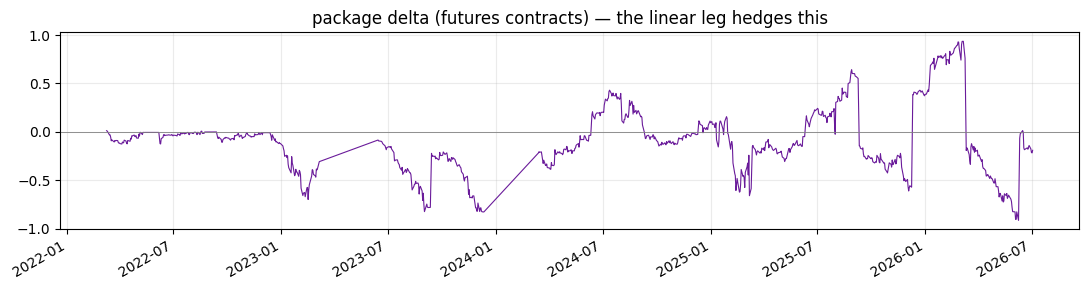

In [4]:
if CONFIG["hedge"]:
    fut_mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")
    bt_h, st_h = make_fly_backtest(
        schedule, sessions, opt_mdp, fut_mdp=fut_mdp,
        contracts=CONFIG["contracts"], side=CONFIG["side"],
        tcost_vol_bp=CONFIG["tcost_vol_bp"],
        tcost_linear_bp=CONFIG["tcost_linear_bp"],
        hedge=True, hedge_threshold=CONFIG["hedge_threshold"],
        show_progress=True)
    bt_h.run()
    cl_h = closed_positions_frame(bt_h)
    eq_h = pd.Series(bt_h.mtm_history).sort_index()
    lin_cost = linear_cost_usd(st_h, CONFIG["tcost_linear_bp"])
    total_h = cl_h["realized_pnl"].sum() - lin_cost
    d_h = eq_h.diff().dropna()
    sdh = d_h.std(ddof=1)
    print(f"hedged: {len(cl_h)} closed, engine PnL "
          f"${cl_h['realized_pnl'].sum():+,.0f}, "
          f"{st_h.n_rebalances} rebalances / "
          f"{st_h.linear_traded_contracts:.1f} futures contracts traded, "
          f"linear cost ${lin_cost:,.0f} -> net ${total_h:+,.0f}")
    print(f"daily MTM (pre-linear-cost): Sharpe "
          f"{d_h.mean() / sdh * np.sqrt(252):+.2f}  "
          f"NW t {nw_tstat(d_h.to_numpy()):+.2f}  "
          f"maxDD ${(eq_h - eq_h.cummax()).min():,.0f}  "
          f"worst day ${d_h.min():,.0f}")
    if st_h.deltas:
        ds = pd.Series(st_h.deltas).sort_index()
        fig, ax = plt.subplots(figsize=(11, 3))
        ax.plot(ds.index, ds.values, lw=0.8, color="#6a1b9a")
        ax.axhline(0, color="grey", lw=0.6)
        ax.set_title("package delta (futures contracts) — the linear leg "
                     "hedges this")
        ax.grid(alpha=0.25)
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

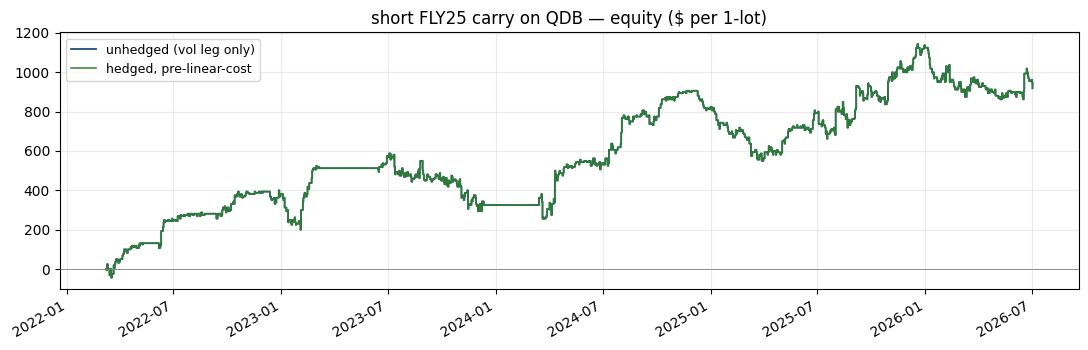

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.step(eq_u.index, eq_u.values, where="post", lw=1.3, color="#1f4e79",
        label="unhedged (vol leg only)")
if CONFIG["hedge"]:
    ax.step(eq_h.index, eq_h.values, where="post", lw=1.1, color="#2e7d32",
            label="hedged, pre-linear-cost")
ax.axhline(0, color="grey", lw=0.6)
ax.set_title(f"{CONFIG['side']} FLY25 carry on QDB — equity ($ per 1-lot)")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Reconciliation vs the research replay

In [6]:
rep_rows = []
sgn = -1.0 if CONFIG["side"] == "short" else 1.0
for h in holdings:
    gross = sgn * float(h.marks.iloc[-1] - h.marks.iloc[0]) * 25.0
    rep_rows.append({"symbol": h.symbol,
                     "start": h.marks.index[0].date(),
                     "replay_gross_usd": gross})
rep = pd.DataFrame(rep_rows)
q = cl_u.copy()
q["start"] = pd.to_datetime(q["opened_at"]).dt.tz_localize(None).dt.date
fee_rt = 2 * 4 * CONFIG["contracts"] * CONFIG["tcost_vol_bp"] * 25.0
q["gross_usd"] = q["realized_pnl"] + fee_rt
m = rep.merge(q[["start", "gross_usd"]], on="start", how="inner")
print(f"matched holdings: {len(m)}/{len(rep)}")
if len(m):
    m["diff_usd"] = m["gross_usd"] - m["replay_gross_usd"]
    print(m.round(1).to_string(index=False))
    print(f"\nmean |diff| ${m['diff_usd'].abs().mean():.1f}   "
          f"corr {np.corrcoef(m['replay_gross_usd'], m['gross_usd'])[0, 1]:.3f}")

matched holdings: 15/18
symbol      start  replay_gross_usd  gross_usd  diff_usd
SFRM22 2022-03-08             129.6      131.2       1.6
SFRU22 2022-06-07             173.2      175.0       1.8
SFRZ22 2022-09-13             135.6      137.5       1.9
SFRH23 2022-12-13             170.1      168.7      -1.3
SFRU23 2023-06-13             -32.7      -31.3       1.4
SFRZ23 2023-09-12            -107.7     -106.2       1.4
SFRM24 2024-03-12             226.3      225.0      -1.3
SFRU24 2024-06-11             287.6      287.5      -0.1
SFRZ24 2024-09-10             120.0      118.8      -1.3
SFRH25 2024-12-10            -284.5     -281.2       3.2
SFRM25 2025-03-11             156.3      156.2      -0.0
SFRU25 2025-06-10             252.2      243.7      -8.5
SFRZ25 2025-09-09             110.5      112.5       2.0
SFRH26 2025-12-09            -114.7     -112.5       2.2
SFRM26 2026-03-10              45.5       50.0       4.5

mean |diff| $2.2   corr 1.000


## T-cost sensitivity — both legs

Fees are additive, so the grid is closed-form off the executed runs: the
vol leg pays per roll, the linear leg pays per traded hedge contract.

In [7]:
gross_total = cl_u["realized_pnl"].sum() + len(cl_u) * fee_rt
rows = []
for tv in CONFIG["vol_tcost_grid"]:
    vol_cost = len(cl_u) * 2 * 4 * CONFIG["contracts"] * tv * 25.0
    for tl in CONFIG["linear_tcost_grid"]:
        lin = (linear_cost_usd(st_h, tl) if CONFIG["hedge"] else 0.0)
        rows.append({
            "tcost_vol_bp": tv, "tcost_linear_bp": tl,
            "unhedged_net_usd": round(gross_total - vol_cost, 0),
            "hedged_net_usd": round(
                (cl_h["realized_pnl"].sum() + len(cl_h) * fee_rt
                 - len(cl_h) * 2 * 4 * CONFIG["contracts"] * tv * 25.0
                 - lin), 0) if CONFIG["hedge"] else np.nan,
        })
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))
print(f"\n(vol leg: {len(cl_u)} rolls x 8 contract-sides; linear leg: "
      f"{st_h.linear_traded_contracts:.1f} traded contracts)"
      if CONFIG["hedge"] else "")

 tcost_vol_bp  tcost_linear_bp  unhedged_net_usd  hedged_net_usd
        0.000             0.00            1275.0          1550.0
        0.000             0.25            1275.0          1508.0
        0.000             0.50            1275.0          1467.0
        0.125             0.00             900.0           900.0
        0.125             0.25             900.0           858.0
        0.125             0.50             900.0           817.0
        0.250             0.00             525.0           250.0
        0.250             0.25             525.0           208.0
        0.250             0.50             525.0           167.0

(vol leg: 15 rolls x 8 contract-sides; linear leg: 6.6 traded contracts)


## Read before using

The carry remains statistically uncertified (NW t < 2 in the replay and
here); this port exists so the two-sleeve combined book (fade + carry)
can run forward under ONE portfolio engine with production marks, and so
both legs' execution assumptions are explicit dials rather than baked-in
constants.